In [179]:
from langgraph.graph import StateGraph , END , START
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_groq import ChatGroq
from typing import TypedDict, List
from dotenv import load_dotenv
import time

In [180]:
load_dotenv()

True

In [181]:
model = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
)

In [182]:
class SequentialState(TypedDict):
    topic: str
    outline: str
    context : str
    blog: str

def gen_outline(state: SequentialState)->SequentialState:
    """preparess an outline for the Blog"""
    start = time.time()
    # extracting the topic blog
    topic = state['topic']
    # form a prompt 
    prompt= f"You are a planner for writing a blog you just have to give a basic outline for this blog just what should be the heading and subheadings {topic}"
    # call the model
    response = model.invoke(prompt).content
    print(f"Outline: {time.time() - start:.2f}s")
    return {
        "outline": response
    }

def search(state: SequentialState)->SequentialState:
    """do web searches using a query"""
    start = time.time()
    wrapper= DuckDuckGoSearchAPIWrapper()
    query = state['topic']
    results = wrapper.results(query, max_results=8)
    snippets = [item["snippet"] for item in results]
    print(f"Search: {time.time() - start:.2f}s")
    return {
        "context": "\n\n".join(snippets)
    }

def blog(state: SequentialState)->SequentialState:
    """write the Blog"""
    start = time.time()
    # extracting the topic blog
    topic = state['topic']
    outline= state['outline']
    context= state['context']

    # form a prompt 
    prompt = f"""
    You are an expert blog writer.

    Topic:
    {topic}

    Outline:
    {outline}

    Research Material:
    {context}

    Write a detailed blog using the outline and research.
    """
    # call the model
    response = model.invoke(prompt).content
    state['blog'] = response
    print(f"Blog: {time.time() - start:.2f}s")
    return state



In [183]:
graph= StateGraph(SequentialState)
graph.add_node('Outline',gen_outline)
graph.add_node('search',search)
graph.add_node('write_blog',blog)

In [184]:
graph.add_edge(START, "Outline")
graph.add_edge(START, "search")

graph.add_edge("Outline", "write_blog")
graph.add_edge("search", "write_blog")

graph.add_edge("write_blog", END)

In [185]:
app = graph.compile()

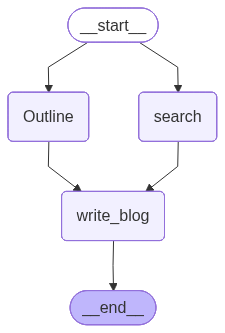

In [186]:
graph.compile()

In [187]:
result = app.invoke(
    {
        "topic": "DVC"
    }
)

Search: 1.83s
Outline: 6.34s
Blog: 3.89s


In [188]:
result['blog']

'<think>\nOkay, I need to write a detailed blog about DVC based on the outline provided. Let me start by understanding the user\'s query. They mentioned "DVC" but the research material includes multiple meanings: Data Version Control, Damodar Valley Corporation, and Disney Vacation Club. However, the outline is about Data Version Control (DVC), so I should focus on that. The user probably wants a blog explaining DVC in the context of data science, not the other entities.\n\nFirst, I\'ll follow the outline structure. The introduction should define DVC and its importance. The research material has some conflicting info, so I need to ignore the parts about Damodar Valley Corporation and Disney Vacation Club. The outline\'s sections are clear, so I\'ll expand each one with relevant details.\n\nFor the introduction, I\'ll explain what DVC is, why it\'s needed in data science, and how it differs from Git. Then, in the core features section, I\'ll list data versioning, pipeline management, Gi

In [189]:
result['context']

"3 days ago - Damodar Valley Corporation (DVC) is a statutory corporation which operates in the Damodar River area of West Bengal and Jharkhand states of India to handle the Damodar Valley Project, the first multipurpose river valley project of independent India. Astrophysicist Meghnad Saha played a pioneering ...\n\n3 days ago - Disney Vacation Development, LLC, operating as Disney Vacation Club (DVC), is a vacation timeshare program of The Walt Disney Company. The program allows members to purchase a real estate interest in a DVC resort through a points-based system. There are an estimated 250,000 members.\n\nApril 16, 2026 - 1 Notice for regulation of power to JBVNL (PDF,824.35 KB) 2 Deferment of Notice for regulation of power to JBVNL (PDF,535.74 KB) 3 Notice to Consumers (PDF,29.10 KB) 4 Notice to DVC Consumers (PDF,51.59 KB) 5 JBVNL REGULATION NOTICE (PDF,109.35 KB) 6 Withdrawal of Regulation of power supply to M/s Jharkhand Bijli Vitran Nigam Limited(JBVNL) (PDF,65.77 KB) 7 Regu

In [190]:
result['outline']

'<think>\nOkay, the user wants a basic outline for a blog about DVC. Let me start by understanding what DVC is. DVC stands for Data Version Control, right? It\'s a tool for managing data science projects. So the blog should explain what DVC is, its features, how to use it, and maybe some best practices.\n\nFirst, the main heading should be something catchy but clear. Maybe "Mastering Data Science Workflows with DVC: A Comprehensive Guide". That sounds good. Now, the subheadings. Let me think about the structure. Usually, a blog starts with an introduction. Then an overview of the tool. Next, key features. After that, a step-by-step guide or tutorial. Then use cases or examples. Best practices, and a conclusion.\n\nWait, the user mentioned "DVC" in the query. Maybe they want to focus on Data Version Control specifically. So the introduction should define DVC and its importance in data science. The overview can explain how it differs from traditional version control like Git. Key feature